# YULU Business Case Study
**Moving India towards asustainable future**


Yulu is an Indian company that rents out electric bikes and scooters through a mobile app. Most of its customers are delivery riders from apps like Blinkit, Zepto and Swiggy Instamart, who subscribe to a Yulu e-bike on a weekly plan instead of buying one. This saves them the cost of a vehicle and the hassle of charging at home they just swap a battery at a nearby station in a few minutes.






## Business Problem
Yulu's revenue has dropped due to declining daily bike rentals. The objective of this project is to analyze operational data to understand exactly what drives customer demand. By evaluating the impact of weather, holidays, and work schedules on rental volumes, this analysis will help Yulu forecast future demand, optimize bike placement, and recover lost revenue.

**Business Question:**

- Which variables are significant in predicting the demand for shared electric cycles in the Indian market?
- How well those variables describe the electric cycle demands


**Data Dictionary:**

* datetime: datetime
* season: season (1: spring, 2: summer, 3: fall, 4: winter)
* holiday: whether day is a holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
* workingday: if day is neither weekend nor holiday is 1, otherwise is 0.
* weather:
  * 1: Clear, Few clouds, partly cloudy, partly cloudy
  * 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  * 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  * 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
* temp: temperature in Celsius
* atemp: feeling temperature in Celsius
* humidity: humidity
* windspeed: wind speed
* casual: count of casual users
* registered: count of registered users
* count: count of total rental bikes including both casual and registered

## Setup

In [44]:
# Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from scipy.stats import ttest_ind, ttest_rel
from scipy.stats import shapiro, levene
from scipy.stats import kruskal
from scipy.stats import chisquare , chi2_contingency
from scipy.stats import f_oneway


In [45]:
!wget https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089 -O yulu.csv

--2026-09-24 10:01:41--  https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/428/original/bike_sharing.csv?1642089089
Resolving d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)... 18.64.229.71, 18.64.229.91, 18.64.229.135, ...
Connecting to d2beiqkhq929f0.cloudfront.net (d2beiqkhq929f0.cloudfront.net)|18.64.229.71|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 648353 (633K) [text/plain]
Saving to: ‘yulu.csv’

yulu.csv            100%[===================>] 633.16K  --.-KB/s    in 0.05s   

2026-09-24 10:01:41 (13.4 MB/s) - ‘yulu.csv’ saved [648353/648353]



In [46]:
# Loading dataset
df= pd.read_csv('yulu.csv')

## Basic data exploration

In [47]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [48]:
df.shape

(10886, 12)

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [50]:
df.isna().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [51]:
df.nunique()

,0
datetime,10886
season,4
holiday,2
workingday,2
weather,4
temp,49
atemp,60
humidity,89
windspeed,28
casual,309


In [52]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


**Insights**

- The count distribution is right-skewed with high-end outliers, indicating occasional massive spikes in daily demand.
- Temperatures range from 0.82°C to 41°C, confirming extreme weather is a key driver of operations.
- Certain days show exactly zero rentals, highlighting potential severe weather events or system outages that need investigation.


In [53]:
# Dropping Highly Correlated variable

df.drop('atemp',axis=1,inplace=True)

### Changing data types

In [54]:
# object to datetime format
df['datetime'] = pd.to_datetime(df['datetime'],errors='coerce')

# integer to categorical format for the better optimization

cat_cols = ['season', 'holiday',	'workingday', 'weather']

for i in cat_cols:
  df[i] = df[i].astype('category')

## Univariate analysis

In [55]:
for i in cat_cols:
  print(df[i].value_counts().sort_index())
  print('-'*20)

season
1    2686
2    2733
3    2733
4    2734
Name: count, dtype: int64
--------------------
holiday
0    10575
1      311
Name: count, dtype: int64
--------------------
workingday
0    3474
1    7412
Name: count, dtype: int64
--------------------
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64
--------------------


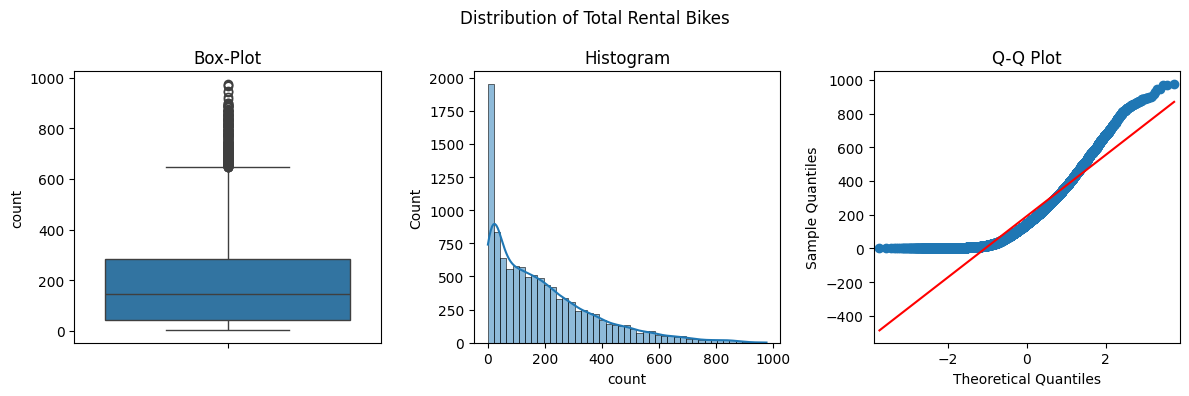

In [56]:
fig, axes = plt.subplots(1,3,figsize=(12,4))
sns.boxplot(df['count'],ax = axes[0])
axes[0].set_title('Box-Plot')

sns.histplot(df['count'],kde=True,ax=axes[1])
axes[1].set_title('Histogram')

sm.qqplot(df['count'],line='s',ax=axes[2])
axes[2].set_title('Q-Q Plot')

plt.suptitle('Distribution of Total Rental Bikes')
plt.tight_layout()
plt.show()


Distribution of count is right-skewed.

In [57]:
num_cols = df.select_dtypes(include='number').columns.to_list()
for i in ['casual','registered','count']:
  if i in num_cols:
    num_cols.remove(i)
print(num_cols)

['temp', 'humidity', 'windspeed']


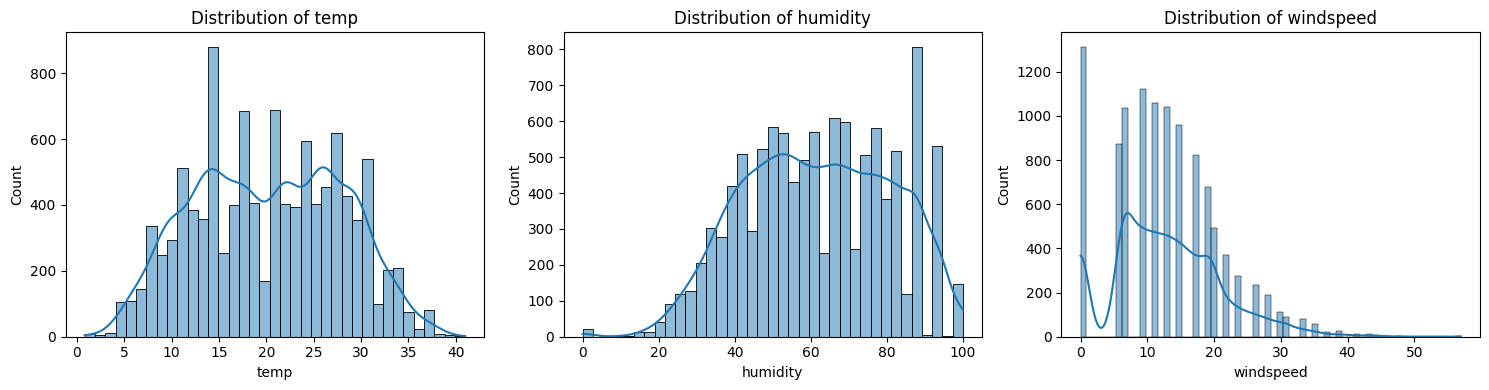

In [58]:
fig,axes = plt.subplots(1,3,figsize=(15,4))


for i, cols in enumerate(num_cols):
  sns.histplot(df[cols],ax = axes[i],kde=True)
  axes[i].set_title(f'Distribution of {cols}')

plt.tight_layout()
plt.show()

## Bivairate Analysis

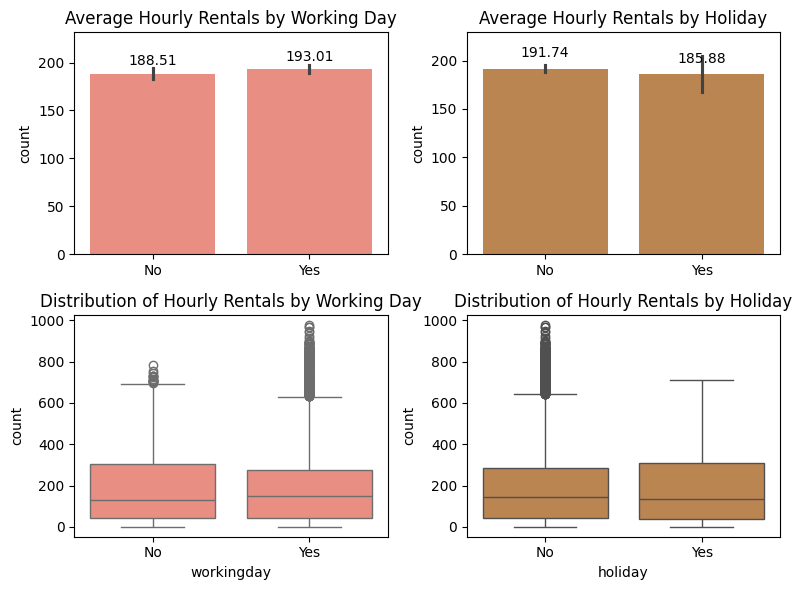

In [59]:
fig,axes = plt.subplots(2,2,figsize=(8,6))
axes = axes.flatten()
a= sns.barplot(data=df,x = 'workingday',y = 'count',ax = axes[0],color='salmon')
for i in a.containers:
  a.bar_label(i,padding=4,fmt = '%.2f')
axes[0].set_title(f'Average Hourly Rentals by Working Day')
axes[0].set_xlabel('')
axes[0].set_ylim(0,193*1.2)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No','Yes'])

b = sns.barplot(data=df,x = 'holiday',y = 'count',ax = axes[1],color='peru')
for i in b.containers:
  b.bar_label(i,padding=6,fmt = '%.2f')
axes[1].set_title(f'Average Hourly Rentals by Holiday')
axes[1].set_xlabel('')
axes[1].set_ylim(0,191*1.2)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No','Yes'])

sns.boxplot(data=df,x = 'workingday',y = 'count',ax = axes[2],color='salmon')
axes[2].set_title(f'Distribution of Hourly Rentals by Working Day')
axes[2].set_xlabel('workingday')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['No','Yes'])

sns.boxplot(data=df,x = 'holiday',y = 'count',ax = axes[3],color='peru')
axes[3].set_title(f'Distribution of Hourly Rentals by Holiday')
axes[3].set_xlabel('holiday')
axes[3].set_xticks([0, 1])
axes[3].set_xticklabels(['No','Yes'])

plt.tight_layout()
plt.show()

The average number of rented bikes is about the same on workdays and weekends. However, workdays have huge, sudden spikes in rentals

People rent slightly fewer bikes on average during holidays. Also, those massive sudden spikes in demand completely disappear on holidays.

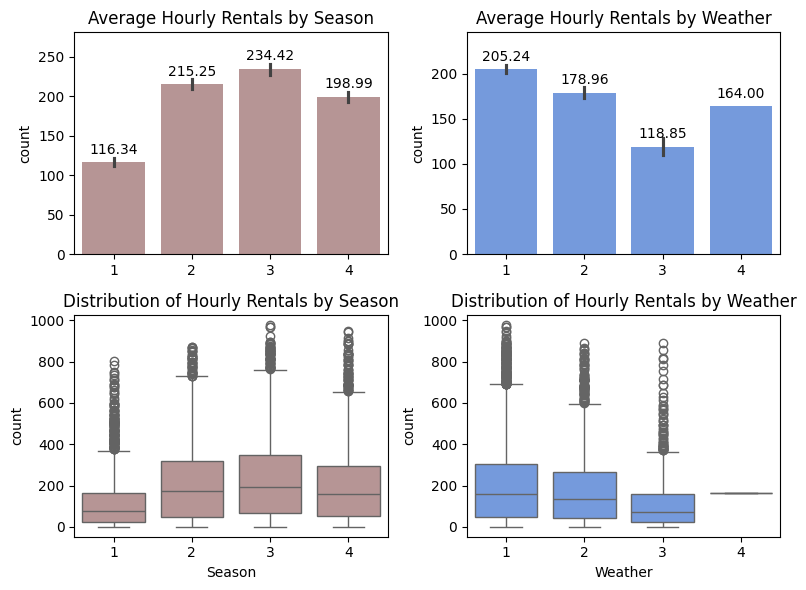

In [60]:
fig,axes = plt.subplots(2,2,figsize=(8,6))
axes = axes.flatten()
a = sns.barplot(data=df,x = 'season',y = 'count',ax = axes[0],color='rosybrown')
for i in a.containers:
  a.bar_label(i,padding=4,fmt = '%.2f')
axes[0].set_title(f'Average Hourly Rentals by Season')
axes[0].set_xlabel('')
axes[0].set_ylim(0,234*1.2)

b =sns.barplot(data=df,x = 'weather',y = 'count',ax = axes[1],color='cornflowerblue')
for i in b.containers:
  b.bar_label(i,padding=4,fmt = '%.2f')
axes[1].set_title(f'Average Hourly Rentals by Weather')
axes[1].set_xlabel('')
axes[1].set_ylim(0,205*1.2)

sns.boxplot(data=df,x = 'season',y = 'count',ax = axes[2],color='rosybrown')
axes[2].set_title(f'Distribution of Hourly Rentals by Season')
axes[2].set_xlabel('Season')

sns.boxplot(data=df,x = 'weather',y = 'count',ax = axes[3],color='cornflowerblue')
axes[3].set_title(f'Distribution of Hourly Rentals by Weather')
axes[3].set_xlabel('Weather')


plt.tight_layout()
plt.show()

Fall (Season 3) has the highest number of bike rentals, while Spring (Season 1) has the lowest demand of the year.

Good weather brings out more riders. Demand is highest during weather is clear and drops off significantly as the weather gets worse.

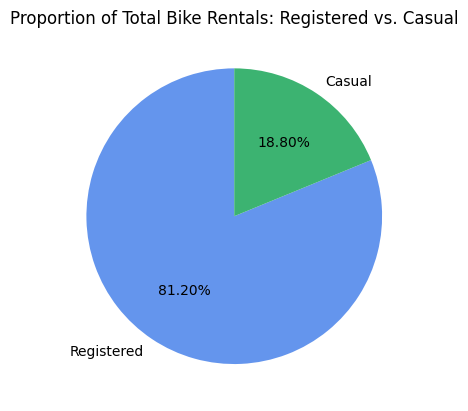

Number of Registered Users: 1693341
Number of Casual Users: 392135


In [61]:
registered = df['registered'].sum()
casual = df['casual'].sum()

labels = ['Registered','Casual']
values = [registered,casual]
plt.pie(values,labels=labels,autopct='%.2f%%',startangle=90,colors=['cornflowerblue','mediumseagreen'])
plt.title('Proportion of Total Bike Rentals: Registered vs. Casual')
plt.show()
print(f'Number of Registered Users: {registered}')
print(f'Number of Casual Users: {casual}')

**Insights**

Most bike rentals come from registered users

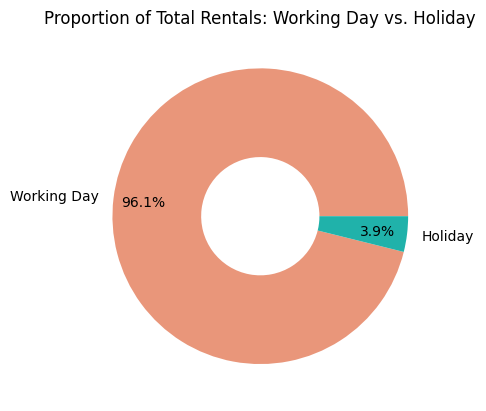

Number of Working Days : 1430604
Number of Holidays: 57808


In [62]:
workingday = df.loc[df['workingday']==1,'count'].sum()
holiday = df.loc[df['holiday']==1,'count'].sum()

labels = ['Working Day','Holiday']
values = [workingday,holiday]
plt.pie(values,labels=labels,autopct='%.1f%%',colors=['darksalmon','lightseagreen'],pctdistance=0.80,wedgeprops={'width':0.60})
plt.title('Proportion of Total Rentals: Working Day vs. Holiday')
plt.show()
print(f'Number of Working Days : {workingday}')
print(f'Number of Holidays: {holiday}')

**Insights**
The vast majority of total bike rentals occur on working days rather than holidays

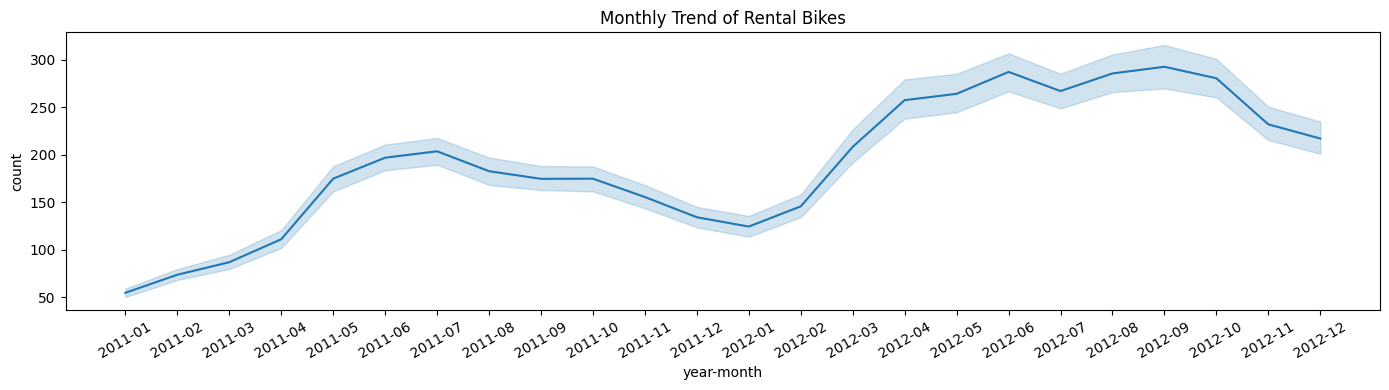

In [63]:
df['year-month'] = df['datetime'].dt.strftime('%Y-%m').astype('object')

plt.figure(figsize=(14,4))
sns.lineplot(data=df,x='year-month',y='count')
plt.xticks(rotation = 30)
plt.title('Monthly Trend of Rental Bikes')
plt.tight_layout()
plt.show()

- Overall bike rentals are significantly higher in 2012 compared to 2011.
- Demand consistently increases mid-year months (fall/summer) and drops in winter.
- The shaded channel shows the variance or spread of daily rentals during that specific month.


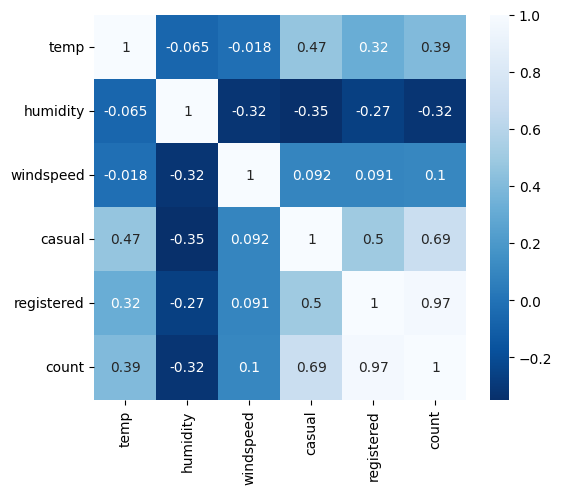

In [64]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='Blues_r')
plt.show()

**Insights**

temp and atemp are nearly identical (0.98 correlation)

casual and registered perfectly predict count because they add up to it.   Temperature

Warmer weather leads to more bike rentals (0.39 correlation).   

Humidity Decreases Demand: High humidity leads to fewer bike rentals (-0.32 correlation).

Windspeed has almost zero impact on total rentals (0.10 correlation).

## Hypothesis Testing

### Q1 . Effect of working days on rental bikes

Describing Null Hypothesis(Ho) and Alternative Hypothesis(Ha)

Null Hypothesis (Ho): Working day has no significant effect on the number of cycles rented (the mean number of rentals on working days is equal to non-working days).Alternate Hypothesis

(Ha): Working day has a significant effect on the number of cycles rented (the mean number of rentals on working days is different from non-working days).

- Significance level / Alpha = 0.05

In [65]:
working_day = df.loc[df['workingday']==1, 'count']
non_working_day = df.loc[df['workingday']==0, 'count']

In [66]:
# T-test Independent

t_stats, p_value = ttest_ind(working_day,non_working_day,alternative='two-sided')

# Compairing P_value with alpha

if p_value < 0.05:
  print(f'P_Value: {p_value}')
  print('Result: Reject Null Hypothesis')
  print('There is a significant effect on the number of cycles rented on working and non working days')
else:
  print(f'P_Value: {p_value}')
  print('Result: Fail to reject Null Hypothesis')
  print('There is no significant effect on the number of cycles rented on working and non working days')



P_Value: 0.22644804226361348
Result: Fail to reject Null Hypothesis
There is no significant effect on the number of cycles rented on working and non working days


### Q2 Effect of season on rental bikes.

In [67]:
df.groupby('season',observed=True)['count'].mean()

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


Since we are comparing more than two groups, we must use an ANOVA. However, first, all statistical assumptions must be met."

In [68]:
# Shapiro-Wilk test

# Ho: The data is normally distributed.
# Ha: The data is NOT normally distributed.

stats,p_value = shapiro(df['count'])

if p_value < 0.05:
    print(f'P-Value: {p_value}')
    print('Result: Reject Null Hypothesis')
    print('Conclusion: The rental counts are NOT normally distributed.')
else:
    print(f'P-Value: {p_value}')
    print('Result: Fail to reject Null Hypothesis')
    print('Conclusion: The rental counts are normally distributed.')

P-Value: 5.369837893115507e-68
Result: Reject Null Hypothesis
Conclusion: The rental counts are NOT normally distributed.


/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10886.
  res = hypotest_fun_out(*samples, **kwds)


In [69]:
spring = df.loc[df['season']==1,'count']
summer = df.loc[df['season']==2,'count']
fall = df.loc[df['season']==3,'count']
winter = df.loc[df['season']==4,'count']


# Ho: All groups have equal variance
# Ha: At least one group has a different variance

stats, p_value = levene(spring,summer,fall,winter)

#Compare Pvalue with alpha

if p_value < 0.05:
  print(f'P_Value: {p_value}')
  print('Result: Reject Null Hypothesis')
  print('Conclusion: Variances are unequal (at least one group differs).')
else:
  print(f'P_Value: {p_value}')
  print('Result: Fail to reject Null Hypothesis')
  print('Conclusion: All groups have equal variances')

P_Value: 1.0147116860043298e-118
Result: Reject Null Hypothesis
Conclusion: Variances are unequal (at least one group differs).


**Alternative Approach: Kruskal-Wallis Test**


Because our data failed both the normality and equal variance assumptions, a standard ANOVA may not be perfectly reliable. To ensure accurate results, we will proceed using the Kruskal-Wallis test. This is the standard non-parametric alternative to ANOVA that does not require normal distributions or equal variances.

In [70]:

# Ho: The median is same for all the saeaon.
# Ha: The median is different for at least one season.

stats, p_value = kruskal(spring,summer,fall,winter)

if p_value < 0.05:
  print(f'P_Value: {p_value}')
  print('Result: Reject Null Hypothesis')
  print('Conclusion: The median is different for at least one season..')
else:
  print(f'P_Value: {p_value}')
  print('Result: Fail to reject Null Hypothesis')
  print('Conclusion: The median is same for all the saeaon.')

P_Value: 2.479008372608633e-151
Result: Reject Null Hypothesis
Conclusion: The median is different for at least one season..


same way we will do with Q3

In [71]:
df.groupby('weather',observed=True)['count'].mean()

,count
weather,
1,205.236791
2,178.955540
3,118.846333
4,164.000000


### Q3 effect of weather on rental bikes

In [72]:
clear = df.loc[df['weather']==1,'count']
misty = df.loc[df['weather']==2,'count']
light_rain = df.loc[df['weather']==3,'count']
severe_weather = df.loc[df['weather']==4,'count']

# Ho: All groups have equal variance
# Ha: At least one group has a different variance

stats, p_value = levene(clear,misty,light_rain,severe_weather)

#Compare Pvalue with alpha

if p_value < 0.05:
  print(f'P_Value: {p_value}')
  print('Result: Reject Null Hypothesis')
  print('Conclusion: Variances are unequal (at least one group differs).')
else:
  print(f'P_Value: {p_value}')
  print('Result: Fail to reject Null Hypothesis')
  print('Conclusion: All groups have equal variances')


P_Value: 3.504937946833238e-35
Result: Reject Null Hypothesis
Conclusion: Variances are unequal (at least one group differs).


In [73]:
# Kruskal-Wallis Test

# Ho: The median is same for all the weather.
# Ha: The median is different for at least one weather.

stats, p_value = kruskal(clear,misty,light_rain,severe_weather)

if p_value < 0.05:
  print(f'P_Value: {p_value}')
  print('Result: Reject Null Hypothesis')
  print('Conclusion: The median is different for at least one weather.')
else:
  print(f'P_Value: {p_value}')
  print('Result: Fail to reject Null Hypothesis')
  print('Conclusion: The median is same for all the weather.')

P_Value: 3.501611300708679e-44
Result: Reject Null Hypothesis
Conclusion: The median is different for at least one weather.


### Q4 Are weather and season related to each other?

In [74]:
# Chisquare test

# Ho: Weather and Season are independent (not related)
# Ha: Weather and Season are dependent (related)

val = pd.crosstab(index=df['weather'],columns=df['season']).values

stats, p_value, dof, exp_freq = chi2_contingency(val)

if p_value < 0.05:
  print(f'P_Value: {p_value}')
  print('Result: Reject Null Hypothesis')
  print('Conclusion: Weather and season are dependent (they are related)')
else:
  print(f'P_Value: {p_value}')
  print('Result: Fail to reject Null Hypothesis')
  print('Conclusion: Weather and Season are independent')

P_Value: 1.5499250736864862e-07
Result: Reject Null Hypothesis
Conclusion: Weather and season are dependent (they are related)


In [75]:
bin_edges = [0, 15, 25, 35, 45]

# Define the names for each bin
bin_labels = ['Cold', 'Moderate', 'Warm', 'Hot']

df['temp_cat'] = pd.cut(df['temp'], bins = bin_edges, labels = bin_labels)

In [76]:
Cold = df.loc[df['temp_cat']=='Cold','count']
Moderate = df.loc[df['temp_cat']=='Moderate','count']
Warm = df.loc[df['temp_cat']=='Warm','count']
Hot = df.loc[df['temp_cat']=='Hot','count']

# Kruskal-Wallis Test

# Ho: The median is same for all the temperature categories
# Ha: The median is different for at least one temperature categories

stats, p_value = kruskal(Cold,Moderate,Warm,Hot)

if p_value < 0.05:
  print(f'P_Value: {p_value}')
  print('Result: Reject Null Hypothesis')
  print('Conclusion: The median is different for at least one temperature categories')
else:
  print(f'P_Value: {p_value}')
  print('Result: Fail to reject Null Hypothesis')
  print('Conclusion: The median is same for all the temperature categories')

P_Value: 0.0
Result: Reject Null Hypothesis
Conclusion: The median is different for at least one temperature categories


## Insights:

- count is right-skewed with high-end outliers (occasional massive demand spikes); the normality assumption fails for it

- Average rentals: workingday = 188.5 vs. non-working = 193.0. Independent T-test found no significant difference (p = 0.226)

 - Season significantly affects rentals (Kruskal-Wallis Test,confirms pvalue is less than alpha used instead of ANOVA because Levene's test showed unequal variances across seasons and shapiro test confirm that daya is not normally distributed.
 Hence, two assumptions of anova got failed).

- Weather significantly affects rentals (Kruskal-Wallis,confirms pvalue < alpha).
Bike rentals decrease during rainy, thunderstorm, snowy, and foggy weather conditions.

- Weather and season are statistically dependent (Chi-square, confirms pvalue < alpha)

- temp and atemp are nearly identical (r = 0.98). Warmer temperature correlates with more rentals (r ≈ 0.39).
- Higher humidity correlates with fewer rentals (r = -0.32).
- Windspeed has significantlly no effect (r = 0.10)
- The year-month trend line shows demand rising through 2012 vs. 2011 and dipping in winter months



##  Recommendations:

- Total daily rentals are roughly the same on workdays and holidays. Instead of changing the total number of bikes based on the calendar, focus on moving bikes to high-traffic areas during morning and evening rush hours to handle commuter spikes.

- These are the biggest factors for predicting demand. Ensure maximum bike availability during Fall and clear weather, but expect lower usage (and plan maintenance schedules) during Spring and rainy periods.

- Because certain weather patterns naturally belong to certain seasons, you cannot predict them separately. Always look at them together when forecasting how many bikes will be needed.

- While registered users make up the vast majority of rentals, offering first-ride discounts or referral bonuses is a logical step to grow the casual user base.
  - (Note: Our current analysis focused on overall weather and season impacts, so deeper research into casual user behavior would be the next step to fully prove this).